# Panama Canal Transits — Phase 2 EDA

Working through the checklist from the project plan:

1. Data coverage audit across all sources.
2. Panama transits series + vessel-class breakdown.
3. Gatun Lake level, 60-year record with drought regimes marked.
4. **The threshold story**: transits vs Gatun (relationship is a floor, not a slope).
5. Precipitation & ENSO — the upstream drivers.
6. Chokepoint substitution — Panama vs Suez / Cape / Bab el-Mandeb.
7. US port coast breakdown (USWC vs USEC).
8. MSTL decomposition of Panama transits (weekly + annual).
9. Cross-correlations: precip → lake → transits (lag structure).
10. Structural breaks (CUSUM).
11. Three candidate forecast targets previewed.

Deliberately omitted vs the plan: Baltic Dry Index / FBX freight rates have no free
daily source. Their absence is flagged where they'd otherwise appear.

## Setup

In [1]:
%matplotlib inline
from pathlib import Path
import sys

# Make src importable when running from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# load_all() now queries the DuckDB warehouse when it exists (falls back to
# raw CSVs otherwise). Same DataFrames either way.
from src.data.load import load_all, connect, load_daily_panel, db_path
print(f"Warehouse: {db_path().name}  ({'DB' if db_path().exists() else 'file fallback'})")

data = load_all()
{k: v.shape for k, v in data.items()}

Warehouse: panama.db  (DB)


{'panama': (2806, 21),
 'chokepoints': (11224, 3),
 'gatun': (4639, 2),
 'precip': (4641, 2),
 'enso': (163, 2),
 'advisories': (201, 14),
 'ports': (28040, 32)}

## 1a. Cross-source query via `daily_panel` view

Everything joined on the daily backbone in a single SELECT. This is the
main payoff of the switch to DuckDB — the six-source merge that used to
require a `.merge()` chain is now a view.

In [2]:
# 12 rows spanning the 2023 drought build-up
q = connect().execute('''
    SELECT date_trunc('month', date) AS month,
           AVG(gatun_level_ft)::DECIMAL(5,2)      AS gatun_avg_ft,
           AVG(transits_panama)::DECIMAL(5,1)     AS transits_avg,
           SUM(precip_mm_basin_avg)::DECIMAL(6,0) AS precip_mm_total,
           AVG(oni)::DECIMAL(4,2)                 AS oni_avg,
           AVG(usa_west_container)::DECIMAL(5,1)  AS uswc_containers,
           AVG(usa_east_container)::DECIMAL(5,1)  AS usec_containers
    FROM daily_panel
    WHERE date BETWEEN '2023-01-01' AND '2023-12-31'
    GROUP BY month ORDER BY month
''').df()
q

,month,gatun_avg_ft,transits_avg,precip_mm_total,oni_avg,uswc_containers,usec_containers
0,2023-01-01,87.08,32.7,96.0,-0.54,8.7,20.4
1,2023-02-01,85.62,32.1,52.0,-0.29,7.6,20.4
2,2023-03-01,84.47,32.9,59.0,-0.02,8.3,18.9
3,2023-04-01,83.01,33.8,64.0,0.27,9.4,20.8
4,2023-05-01,80.93,31.0,181.0,0.57,9.7,20.1
5,2023-06-01,79.79,30.6,266.0,0.84,10.0,20.4
6,2023-07-01,79.54,31.6,327.0,1.12,9.2,21.2
7,2023-08-01,79.60,30.9,301.0,1.37,9.6,20.2
8,2023-09-01,79.75,31.0,277.0,1.60,10.4,20.4
9,2023-10-01,79.76,30.1,359.0,1.83,9.4,20.9


## 1. Data coverage audit

One row per source: date range, row count, and % daily coverage over the window.
Any source with <95% coverage in the modelling window (2019+) will need
interpolation or exclusion in feature engineering.

In [3]:
def coverage_row(name, df, date_col="date"):
    d = df[date_col]
    span_days = (d.max() - d.min()).days + 1
    coverage = len(d.drop_duplicates()) / span_days if span_days else np.nan
    return {
        "source": name,
        "rows": len(df),
        "date_min": d.min().date(),
        "date_max": d.max().date(),
        "span_days": span_days,
        "coverage": f"{coverage:.1%}",
    }

rows = [
    coverage_row("panama_transits", data["panama"]),
    coverage_row("gatun_history",   data["gatun"]),
    coverage_row("precip_chagres",  data["precip"]),
    coverage_row("enso_oni",        data["enso"], date_col="month_start"),
    coverage_row("chokepoints",     data["chokepoints"].drop_duplicates("date")),
    coverage_row("ports",           data["ports"].drop_duplicates("date")),
]
pd.DataFrame(rows)

,source,rows,date_min,date_max,span_days,coverage
0,panama_transits,2806,2019-01-01,2026-09-06,2806,100.0%
1,gatun_history,4639,2014-01-01,2026-09-13,4639,100.0%
2,precip_chagres,4641,2014-01-01,2026-09-15,4641,100.0%
3,enso_oni,163,2013-01-01,2026-07-01,4930,3.3%
4,chokepoints,2806,2019-01-01,2026-09-06,2806,100.0%
5,ports,2804,2019-01-01,2026-09-04,2804,100.0%


## 2. Panama Canal transits — the target

Daily n_total (transit calls) with a 7-day moving average. The vessel-class
stacked area below shows compositional shifts — container ships hold booked
slots and are stable; bulkers queue and swing with capacity.

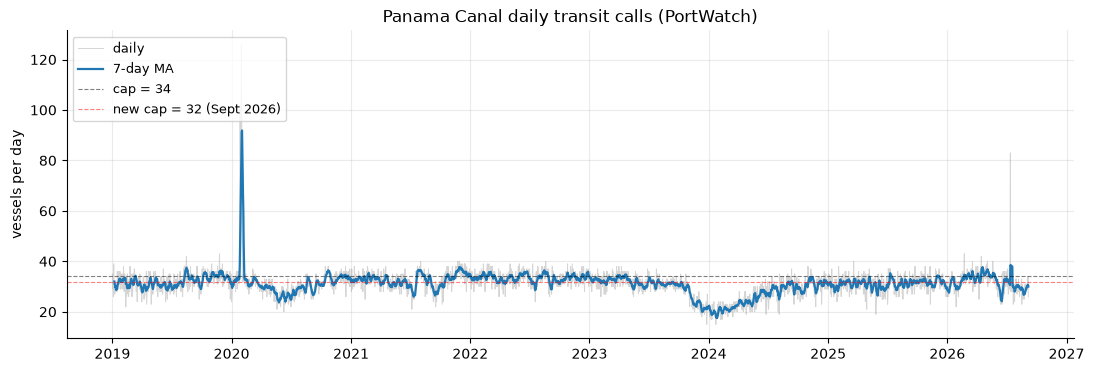

In [4]:
p = data["panama"].copy()
p["n_total_7dma"] = p["n_total"].rolling(7).mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(p["date"], p["n_total"], color="#888", alpha=0.35, lw=0.7, label="daily")
ax.plot(p["date"], p["n_total_7dma"], color="C0", lw=1.6, label="7-day MA")
ax.axhline(34, color="k", ls="--", lw=0.8, alpha=0.5, label="cap = 34")
ax.axhline(32, color="r", ls="--", lw=0.8, alpha=0.5, label="new cap = 32 (Sept 2026)")
ax.set_title("Panama Canal daily transit calls (PortWatch)")
ax.set_ylabel("vessels per day")
ax.legend(loc="upper left", fontsize=9)
plt.show()

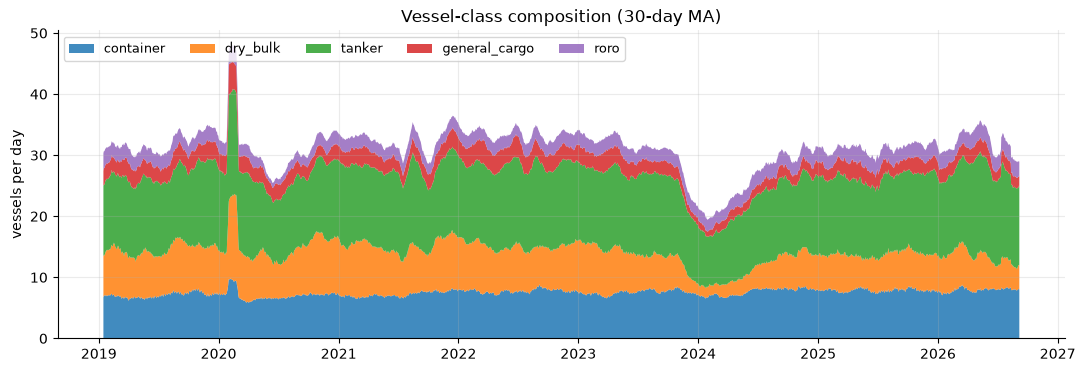

In [5]:
classes = ["n_container", "n_dry_bulk", "n_tanker", "n_general_cargo", "n_roro"]
smooth = p.set_index("date")[classes].rolling(30, min_periods=15).mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.stackplot(smooth.index, [smooth[c] for c in classes],
             labels=[c.replace("n_", "") for c in classes], alpha=0.85)
ax.set_title("Vessel-class composition (30-day MA)")
ax.set_ylabel("vessels per day")
ax.legend(loc="upper left", ncol=5, fontsize=9)
plt.show()

## 3. Gatun Lake — the hero regressor

Two drought windows visible: 2015-16 (moderate El Niño) and the extraordinary
2023-24 event the plan is built around. Warehouse holds 2014+; deeper history
lives in the raw ACP CSV if we ever need a longer climatology.

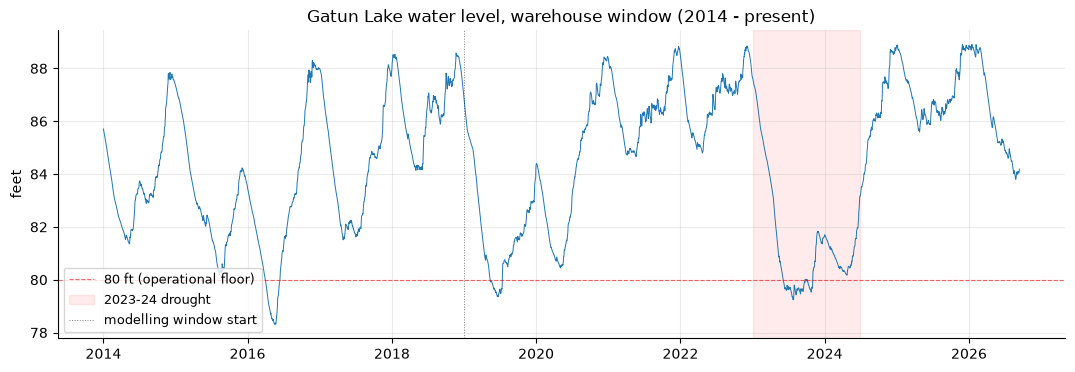

In [6]:
g = data["gatun"].copy()
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(g["date"], g["gatun_level_ft"], lw=0.7, color="C0")
ax.axhline(80, color="r", ls="--", lw=0.8, alpha=0.6, label="80 ft (operational floor)")
ax.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2024-06-30"),
           color="red", alpha=0.08, label="2023-24 drought")
ax.axvline(pd.Timestamp("2019-01-01"), color="k", ls=":", lw=0.7,
           alpha=0.5, label="modelling window start")
ax.set_title("Gatun Lake water level, warehouse window (2014 - present)")
ax.set_ylabel("feet")
ax.legend(loc="lower left", fontsize=9)
plt.show()

## 4. The threshold story: transits vs Gatun

The relationship is a floor, not a slope. Above ~84 ft, ACP runs the full
cap and transits sit at ~34/day. As Gatun drops, ACP announces cap cuts;
transits step down in response. Below ~82 ft, transits are meaningfully
constrained. Plot the joint distribution and time series overlay.

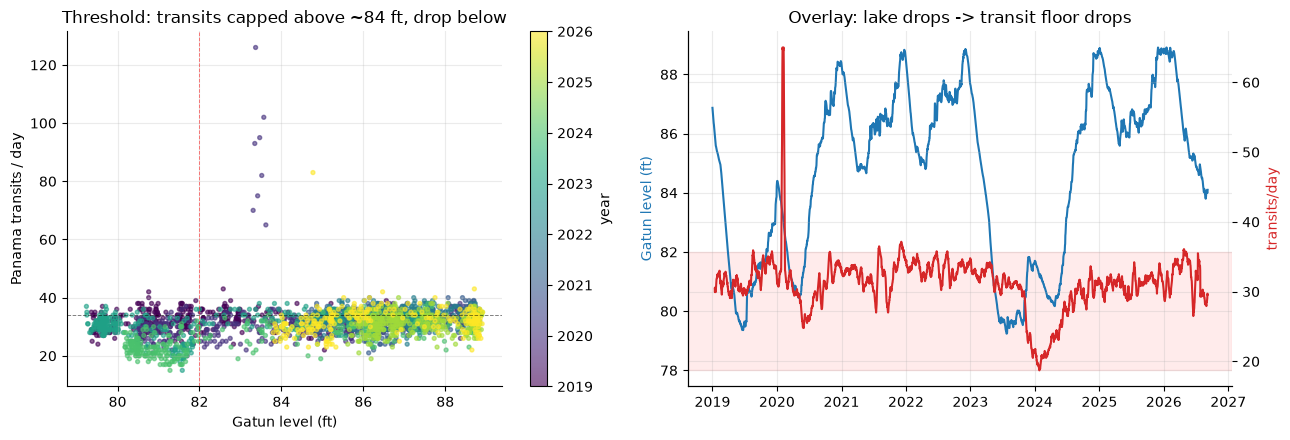

In [7]:
p = data["panama"][["date", "n_total"]].copy()
g = data["gatun"][["date", "gatun_level_ft"]].copy()
j = p.merge(g, on="date", how="inner")
j["year"] = j["date"].dt.year

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sc = axes[0].scatter(j["gatun_level_ft"], j["n_total"], c=j["year"], s=8,
                     alpha=0.6, cmap="viridis")
axes[0].axhline(34, color="k", ls="--", lw=0.7, alpha=0.5)
axes[0].axvline(82, color="r", ls="--", lw=0.7, alpha=0.5)
axes[0].set_xlabel("Gatun level (ft)")
axes[0].set_ylabel("Panama transits / day")
axes[0].set_title("Threshold: transits capped above ~84 ft, drop below")
plt.colorbar(sc, ax=axes[0], label="year")

ax2 = axes[1]
ax2b = ax2.twinx()
ax2.plot(j["date"], j["gatun_level_ft"], color="C0", label="Gatun (ft)")
ax2b.plot(j["date"], j["n_total"].rolling(14).mean(), color="C3", label="transits (14d MA)")
ax2.axhspan(78, 82, color="red", alpha=0.08)
ax2.set_ylabel("Gatun level (ft)", color="C0")
ax2b.set_ylabel("transits/day", color="C3")
ax2.set_title("Overlay: lake drops -> transit floor drops")
plt.tight_layout()
plt.show()

## 5. Precipitation and ENSO — the upstream drivers

Chagres basin precipitation is what ACP is *waiting for* when they cut the
cap. ONI at a 3-6 month lead is the strongest known predictor of Panama
watershed rainfall anomalies.

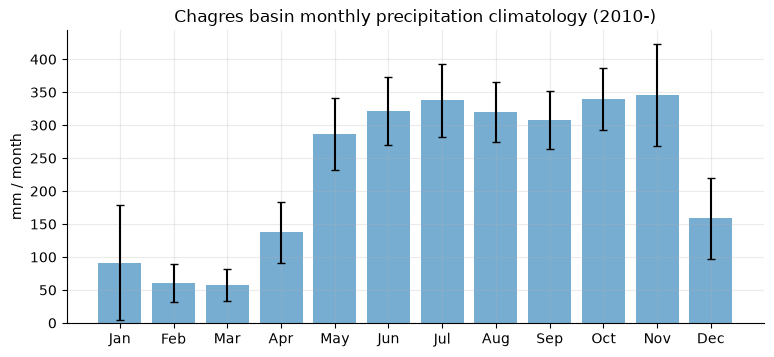

In [8]:
r = data["precip"].copy()
r["year"] = r["date"].dt.year
r["month"] = r["date"].dt.month
monthly = (r.groupby(["year", "month"], as_index=False)["precip_mm_basin_avg"]
             .sum().rename(columns={"precip_mm_basin_avg": "monthly_precip_mm"}))
climatology = monthly.groupby("month")["monthly_precip_mm"].agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(climatology.index, climatology["mean"], yerr=climatology["std"],
       color="C0", alpha=0.6, capsize=3)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Chagres basin monthly precipitation climatology (2010-)")
ax.set_ylabel("mm / month")
plt.show()

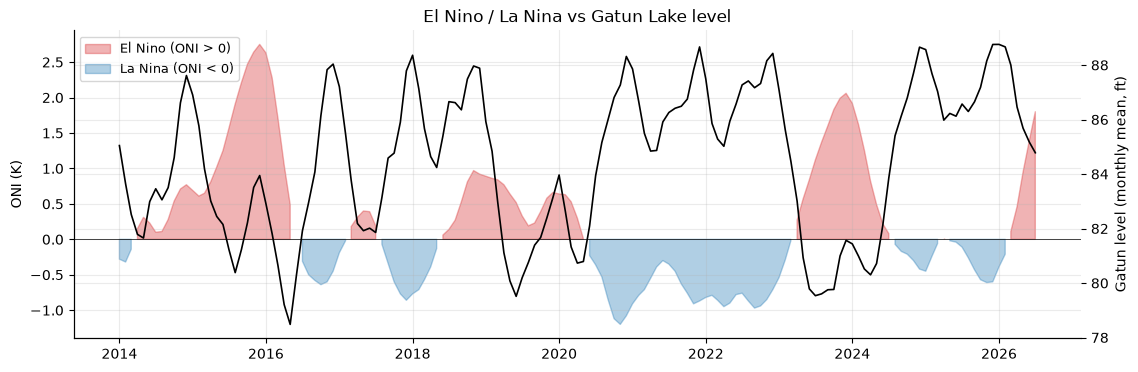

In [9]:
oni = data["enso"].copy()
g = data["gatun"].copy()
g_month = (g.assign(m=g["date"].dt.to_period("M"))
             .groupby("m", as_index=False)["gatun_level_ft"].mean())
g_month["month_start"] = g_month["m"].dt.to_timestamp()
overlay = oni.merge(g_month[["month_start", "gatun_level_ft"]], on="month_start")

fig, ax = plt.subplots(figsize=(13, 4))
ax.axhline(0, color="k", lw=0.5)
ax.fill_between(overlay["month_start"], 0, overlay["oni"],
                where=overlay["oni"] > 0, color="C3", alpha=0.35, label="El Nino (ONI > 0)")
ax.fill_between(overlay["month_start"], 0, overlay["oni"],
                where=overlay["oni"] < 0, color="C0", alpha=0.35, label="La Nina (ONI < 0)")
ax.set_ylabel("ONI (K)")
ax.legend(loc="upper left", fontsize=9)

ax2 = ax.twinx()
ax2.plot(overlay["month_start"], overlay["gatun_level_ft"], color="k", lw=1.2)
ax2.set_ylabel("Gatun level (monthly mean, ft)")
ax.set_title("El Nino / La Nina vs Gatun Lake level")
plt.show()

## 6. Chokepoint substitution

Panama, Suez, Cape of Good Hope, Bab el-Mandeb. Two disruption windows:
- Suez blocked by Ever Given, March 2021 (brief spike at Cape).
- Houthi Red Sea attacks from ~November 2023 -> Bab collapses, Cape absorbs.

Substitution to/from Panama is more subtle — mediated through Asia-US routing.

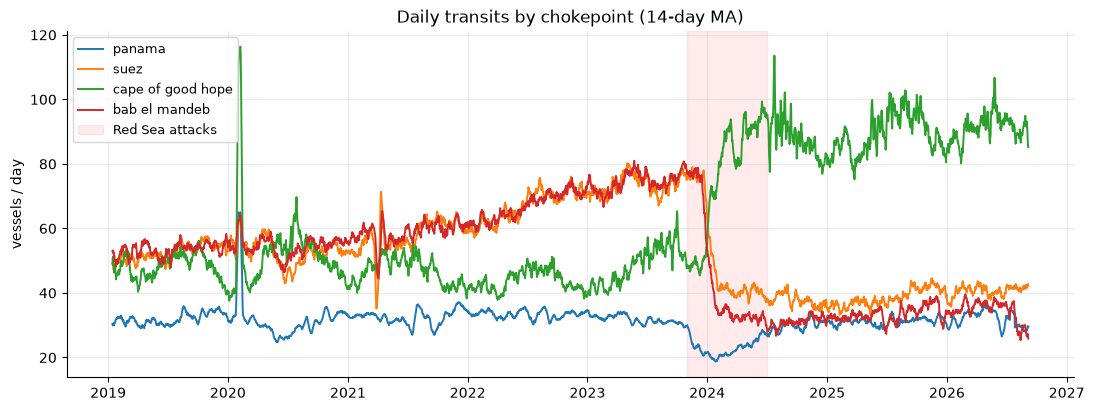

In [10]:
ck = data["chokepoints"].copy()
ck["n_total_7"] = ck.groupby("chokepoint")["n_total"].transform(lambda s: s.rolling(14).mean())

fig, ax = plt.subplots(figsize=(13, 4.5))
order = ["panama", "suez", "cape_of_good_hope", "bab_el_mandeb"]
colors = {"panama": "C0", "suez": "C1", "cape_of_good_hope": "C2", "bab_el_mandeb": "C3"}
for slug in order:
    sub = ck[ck["chokepoint"] == slug]
    ax.plot(sub["date"], sub["n_total_7"], label=slug.replace("_", " "),
            color=colors[slug], lw=1.4)
ax.axvspan(pd.Timestamp("2023-11-01"), pd.Timestamp("2024-06-30"),
           color="red", alpha=0.08, label="Red Sea attacks")
ax.set_title("Daily transits by chokepoint (14-day MA)")
ax.set_ylabel("vessels / day")
ax.legend(loc="upper left", fontsize=9)
plt.show()

## 7. US ports — coast breakdown

USWC / USEC ratio: when Panama capacity tightens, Asia-US container flow
shifts West Coast (LA/LB gain, EC ports lose). Aggregating major container
ports by coast to look for the signal.

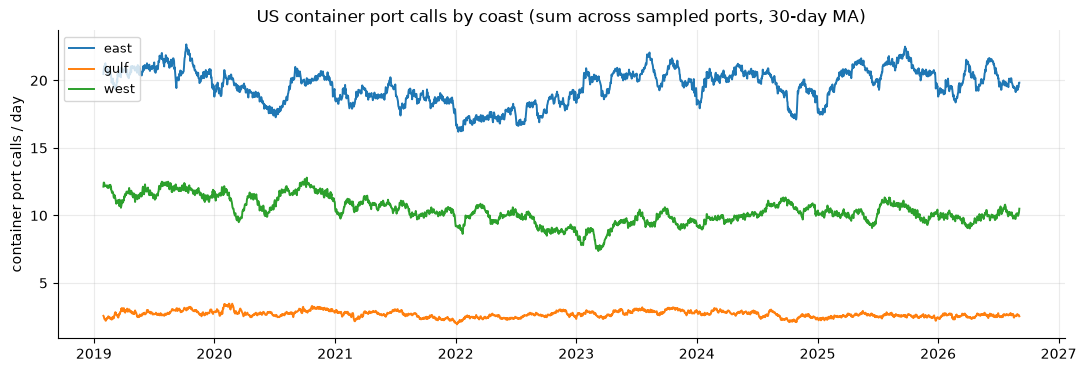

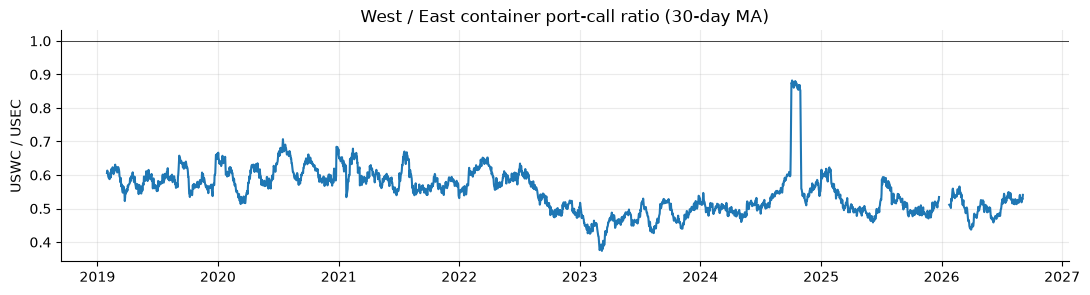

In [11]:
po = data["ports"].copy()
coast_daily = (po.groupby(["date", "coast"], as_index=False)["portcalls_container"]
                 .sum())
coast_daily["ma"] = (coast_daily.groupby("coast")["portcalls_container"]
                                .transform(lambda s: s.rolling(30).mean()))

fig, ax = plt.subplots(figsize=(13, 4))
for coast, sub in coast_daily.groupby("coast"):
    ax.plot(sub["date"], sub["ma"], label=coast, lw=1.4)
ax.set_title("US container port calls by coast (sum across sampled ports, 30-day MA)")
ax.set_ylabel("container port calls / day")
ax.legend(loc="upper left", fontsize=9)
plt.show()

wide = coast_daily.pivot_table(index="date", columns="coast",
                                values="portcalls_container", aggfunc="sum")
wide["west_over_east"] = wide["west"] / wide["east"]
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(wide.index, wide["west_over_east"].rolling(30).mean(), color="C0")
ax.axhline(1.0, color="k", lw=0.5)
ax.set_title("West / East container port-call ratio (30-day MA)")
ax.set_ylabel("USWC / USEC")
plt.show()

## 8. MSTL decomposition of Panama transits

Weekly (period=7) and annual (period=365) seasonality. Check whether weekly
seasonality attenuates during capped periods (2023-24) as the plan expects.

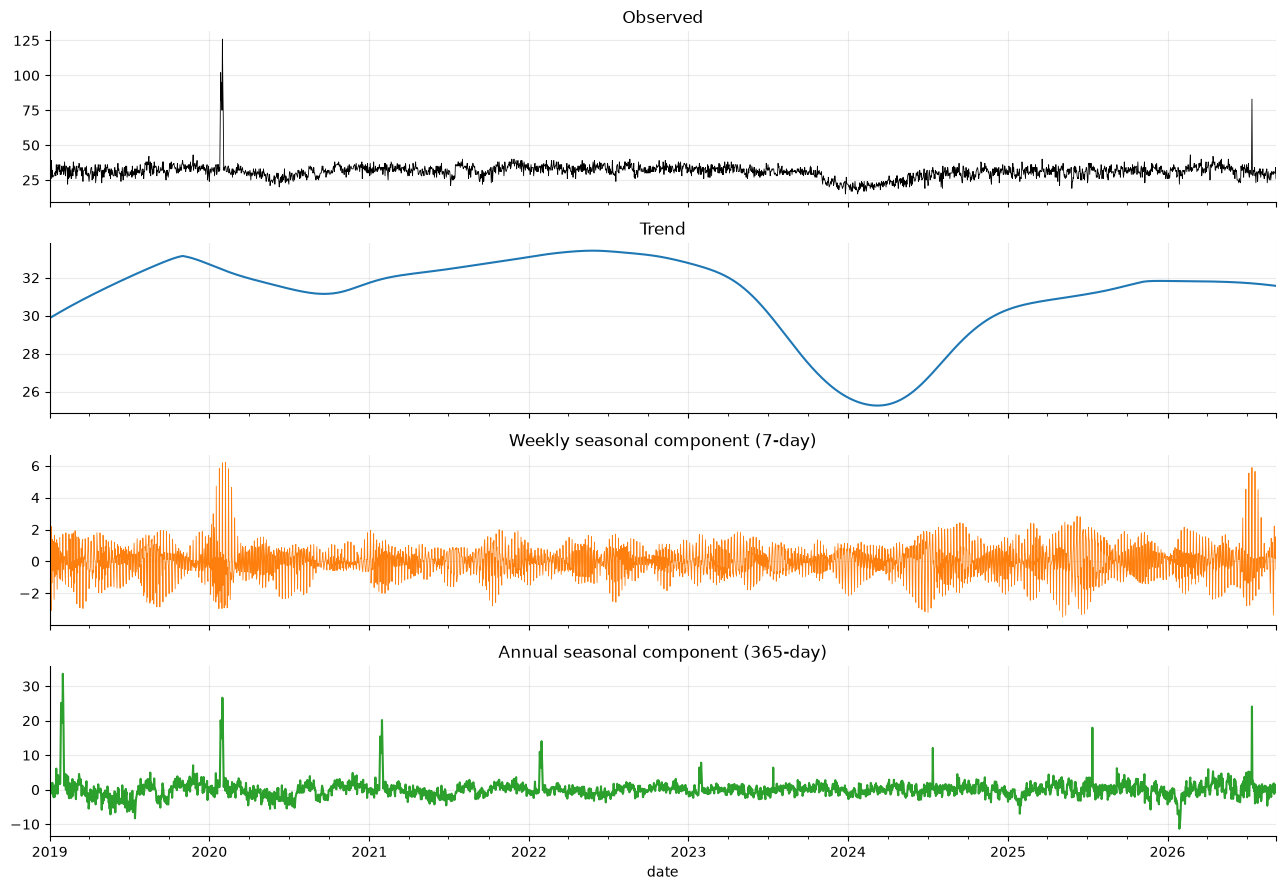

In [12]:
from statsmodels.tsa.seasonal import MSTL

p = data["panama"].set_index("date")["n_total"].asfreq("D").interpolate("linear")
res = MSTL(p, periods=(7, 365)).fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
res.observed.plot(ax=axes[0], color="k", lw=0.6)
axes[0].set_title("Observed")
res.trend.plot(ax=axes[1], color="C0")
axes[1].set_title("Trend")
res.seasonal["seasonal_7"].plot(ax=axes[2], color="C1", lw=0.6)
axes[2].set_title("Weekly seasonal component (7-day)")
res.seasonal["seasonal_365"].plot(ax=axes[3], color="C2")
axes[3].set_title("Annual seasonal component (365-day)")
plt.tight_layout()
plt.show()

## 9. Cross-correlations — the lag structure

Two CCFs the plan calls for:
1. Precipitation → lake level (expect precip to lead by ~2-6 weeks).
2. Lake level → transits (expect lake to lead by 4-12 weeks — because ACP
   announces cap changes based on projections, not present state).

CCF at positive lags = X leads Y.

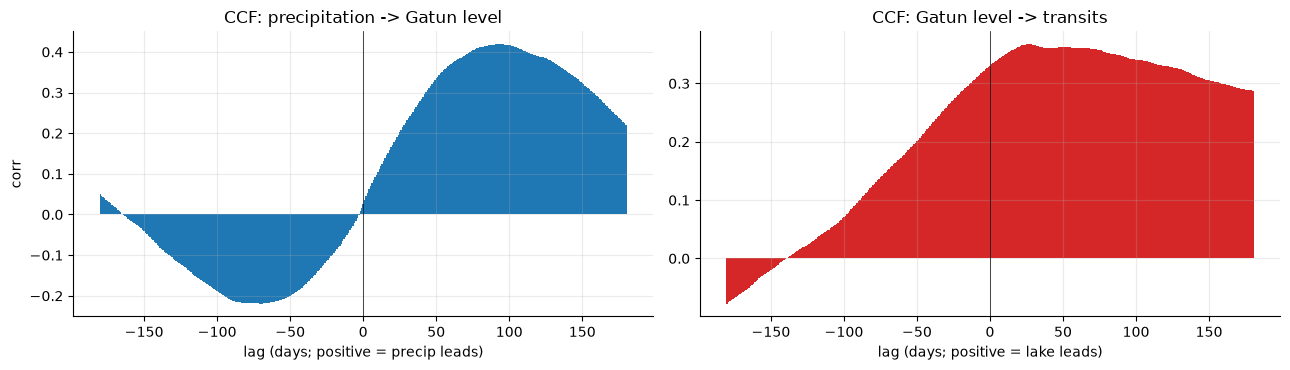

Peak precip -> lake lag:  +93 days
Peak lake  -> transit lag: +26 days


In [13]:
from scipy.signal import correlate

def ccf(x, y, max_lag):
    x = (x - x.mean()) / x.std()
    y = (y - y.mean()) / y.std()
    n = len(x)
    c = correlate(y, x, mode="full") / n
    lags = np.arange(-n + 1, n)
    mask = (lags >= -max_lag) & (lags <= max_lag)
    return lags[mask], c[mask]

p = data["precip"].set_index("date")["precip_mm_basin_avg"].asfreq("D").fillna(0)
g = data["gatun"].set_index("date")["gatun_level_ft"].asfreq("D").interpolate()
t = data["panama"].set_index("date")["n_total"].asfreq("D").interpolate()

start = max(p.index.min(), g.index.min(), t.index.min())
end   = min(p.index.max(), g.index.max(), t.index.max())
p, g, t = p.loc[start:end], g.loc[start:end], t.loc[start:end]

# smooth to weekly to make the CCFs readable
pw = p.rolling(7).sum().dropna()
gw = g.rolling(7).mean().dropna()
tw = t.rolling(7).mean().dropna()
idx = pw.index.intersection(gw.index).intersection(tw.index)
pw, gw, tw = pw.loc[idx], gw.loc[idx], tw.loc[idx]

lags1, ccf1 = ccf(pw.values, gw.values, max_lag=180)  # precip -> lake
lags2, ccf2 = ccf(gw.values, tw.values, max_lag=180)  # lake  -> transits

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].bar(lags1, ccf1, color="C0", width=1)
axes[0].axvline(0, color="k", lw=0.5)
axes[0].set_title("CCF: precipitation -> Gatun level")
axes[0].set_xlabel("lag (days; positive = precip leads)")
axes[0].set_ylabel("corr")

axes[1].bar(lags2, ccf2, color="C3", width=1)
axes[1].axvline(0, color="k", lw=0.5)
axes[1].set_title("CCF: Gatun level -> transits")
axes[1].set_xlabel("lag (days; positive = lake leads)")
plt.tight_layout()
plt.show()

peak_p = lags1[np.argmax(ccf1)]
peak_l = lags2[np.argmax(ccf2)]
print(f"Peak precip -> lake lag:  {peak_p:+d} days")
print(f"Peak lake  -> transit lag: {peak_l:+d} days")

## 10. Structural breaks (CUSUM)

CUSUM of squares on Panama transits to locate regime changes. The plan flags
mid-2023 (drought onset) and mid-2024 (partial recovery). CUSUM should light
up there.

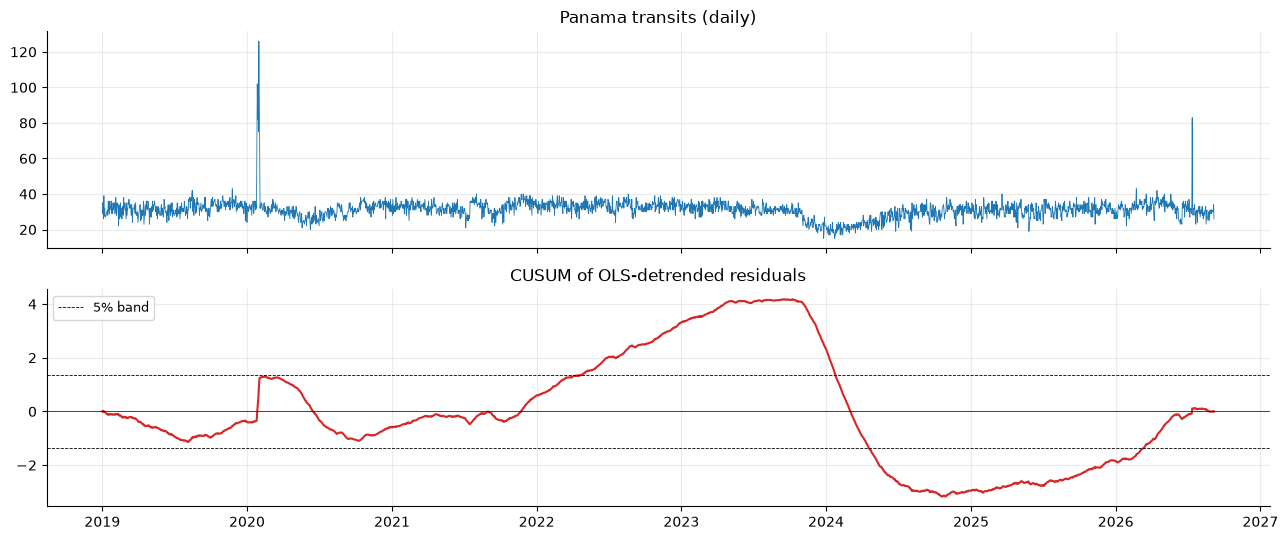

Peak CUSUM deviation on: 2023-09-18


In [14]:
from statsmodels.stats.diagnostic import breaks_cusumolsresid
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

p = data["panama"].set_index("date")["n_total"].asfreq("D").interpolate()

# residuals from a slow trend so CUSUM highlights level shifts, not the seasonality
x = np.arange(len(p))
X = add_constant(x)
resid = OLS(p.values, X).fit().resid

cs = np.cumsum(resid) / (resid.std() * np.sqrt(len(resid)))

fig, axes = plt.subplots(2, 1, figsize=(13, 5.5), sharex=True)
axes[0].plot(p.index, p.values, color="C0", lw=0.6)
axes[0].set_title("Panama transits (daily)")

axes[1].plot(p.index, cs, color="C3")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].axhline(1.36, color="k", ls="--", lw=0.6, label="5% band")
axes[1].axhline(-1.36, color="k", ls="--", lw=0.6)
axes[1].set_title("CUSUM of OLS-detrended residuals")
axes[1].legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

# quick automatic break: date of maximum |CUSUM|
break_date = p.index[np.argmax(np.abs(cs))]
print(f"Peak CUSUM deviation on: {break_date.date()}")

## 11. Three candidate forecast targets

Per the plan:
- `transits_total` — the censored raw count.
- `capacity_utilization` — transits divided by announced daily cap. Approximated
  here as `n_total / rolling_max` until the advisory-derived cap series is
  manually cleaned.
- **`wait_hours` — recovered from ACP monthly summaries** (44 rows, Dec 2021 →
  Aug 2025). `wait = canal_waters_time − in_transit_time`. Monthly grain, not
  daily, but this is the plan's third target and it was thought unavailable.

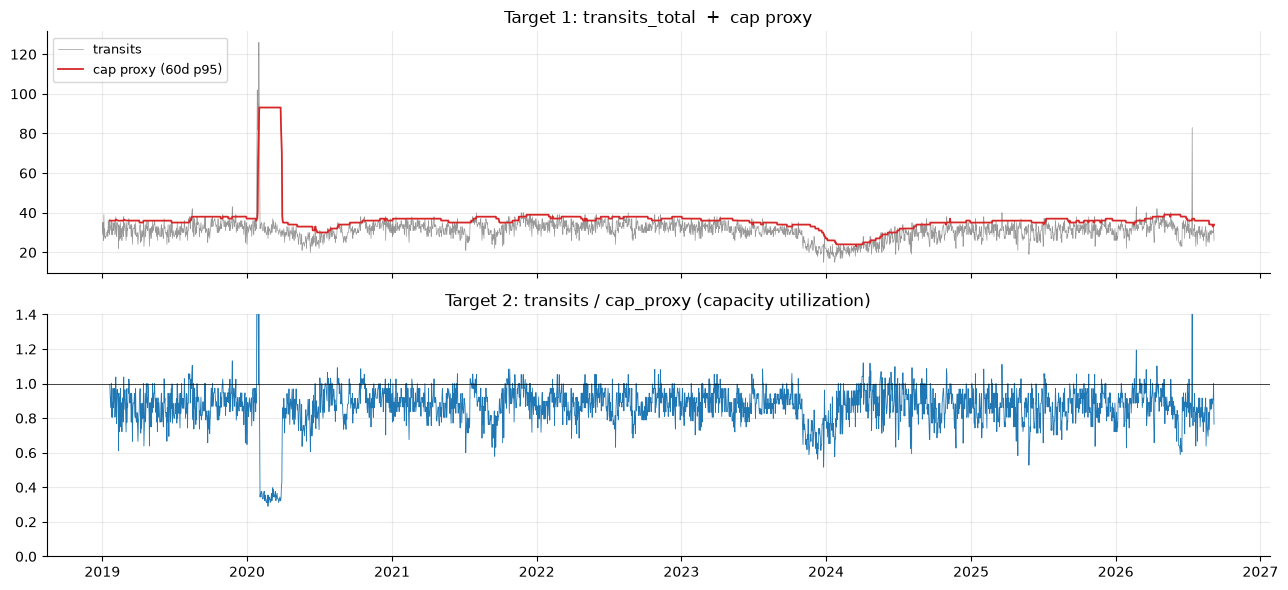

In [15]:
p = data["panama"][["date", "n_total"]].copy()
p["cap_proxy"] = p["n_total"].rolling(60, min_periods=20).quantile(0.95)
p["utilization_proxy"] = p["n_total"] / p["cap_proxy"]

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(p["date"], p["n_total"], color="k", lw=0.5, alpha=0.4, label="transits")
axes[0].plot(p["date"], p["cap_proxy"], color="C3", lw=1.3, label="cap proxy (60d p95)")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].set_title("Target 1: transits_total  +  cap proxy")

axes[1].plot(p["date"], p["utilization_proxy"], color="C0", lw=0.6)
axes[1].axhline(1.0, color="k", lw=0.5)
axes[1].set_ylim(0, 1.4)
axes[1].set_title("Target 2: transits / cap_proxy (capacity utilization)")
plt.tight_layout()
plt.show()

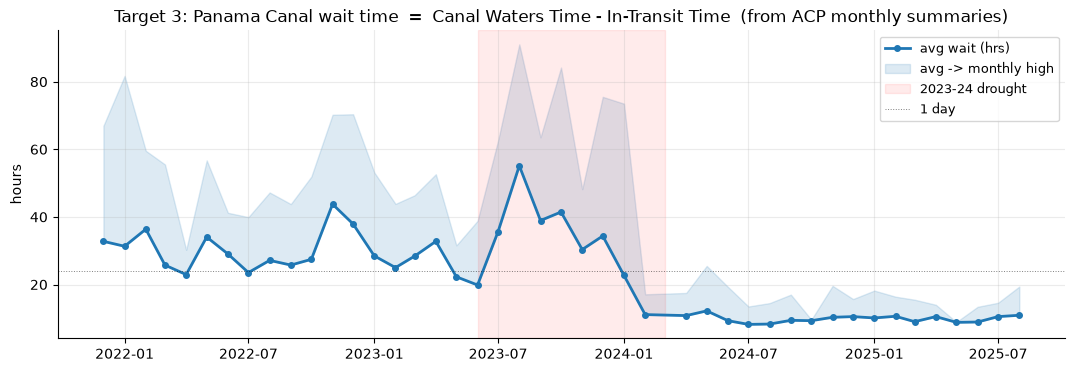

Peak monthly-avg wait: 55.1 hrs (2.3 days) in August 2023
Peak monthly-high:     91.0 hrs (3.8 days)


In [16]:
from src.data.load import load_monthly_ops
mo = load_monthly_ops()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(mo["month_start"], mo["wait_hours_avg"], color="C0", lw=2,
        marker="o", ms=4, label="avg wait (hrs)")
ax.fill_between(mo["month_start"], mo["wait_hours_avg"], mo["wait_hours_high"],
                color="C0", alpha=0.15, label="avg -> monthly high")
ax.axvspan(pd.Timestamp("2023-06-01"), pd.Timestamp("2024-03-01"),
           color="red", alpha=0.08, label="2023-24 drought")
ax.axhline(24, color="k", ls=":", lw=0.7, alpha=0.5, label="1 day")
ax.set_title("Target 3: Panama Canal wait time  =  Canal Waters Time - In-Transit Time  (from ACP monthly summaries)")
ax.set_ylabel("hours")
ax.legend(loc="upper right", fontsize=9)
plt.show()

peak = mo.loc[mo["wait_hours_avg"].idxmax()]
print(f"Peak monthly-avg wait: {peak['wait_hours_avg']:.1f} hrs "
      f"({peak['wait_hours_avg']/24:.1f} days) in {peak['month_start'].strftime('%B %Y')}")
print(f"Peak monthly-high:     {peak['wait_hours_high']:.1f} hrs "
      f"({peak['wait_hours_high']/24:.1f} days)")

## 12. Deep dive: monthly operations metrics

The `monthly_ops` table gives us 44 months of ACP-published operational
metrics: daily-average arrivals, transits, canal-waters-time, in-transit-time,
plus the derived `wait_hours` series. Small (n=44) but every field is
directly meaningful, and this is the only source we have with a queue signal.

In [17]:
from src.data.load import load_monthly_ops
mo = load_monthly_ops()
mo["month_start"] = pd.to_datetime(mo["month_start"])
mo["arrivals_gap"] = mo["arrivals_daily_avg"] - mo["transits_daily_avg"]
mo["month_of_year"] = mo["month_start"].dt.month
print(f"Coverage: {mo['month_start'].min().date()} -> {mo['month_start'].max().date()}  ({len(mo)} months)")
print("\nSummary statistics:")
mo[["arrivals_daily_avg", "transits_daily_avg", "arrivals_gap",
    "canal_waters_hours_avg", "in_transit_hours_avg",
    "wait_hours_avg", "wait_hours_high"]].describe().round(2)

Coverage: 2021-12-01 -> 2025-08-01  (44 months)

Summary statistics:


,arrivals_daily_avg,transits_daily_avg,arrivals_gap,canal_waters_hours_avg,in_transit_hours_avg,wait_hours_avg,wait_hours_high
count,44.00,44.00,44.00,44.00,44.00,44.00,44.00
mean,32.29,32.61,-0.32,33.15,10.61,22.54,40.23
std,3.54,3.82,0.83,12.60,0.63,12.23,23.91
min,22.20,22.60,-2.36,18.30,9.40,8.20,8.90
25%,31.59,31.40,-0.84,20.78,10.20,10.50,17.08
50%,33.10,33.30,-0.36,33.75,10.70,23.23,40.58
75%,34.78,35.45,0.40,42.33,11.05,31.68,57.44
max,36.65,38.06,0.97,66.53,12.27,55.13,91.04


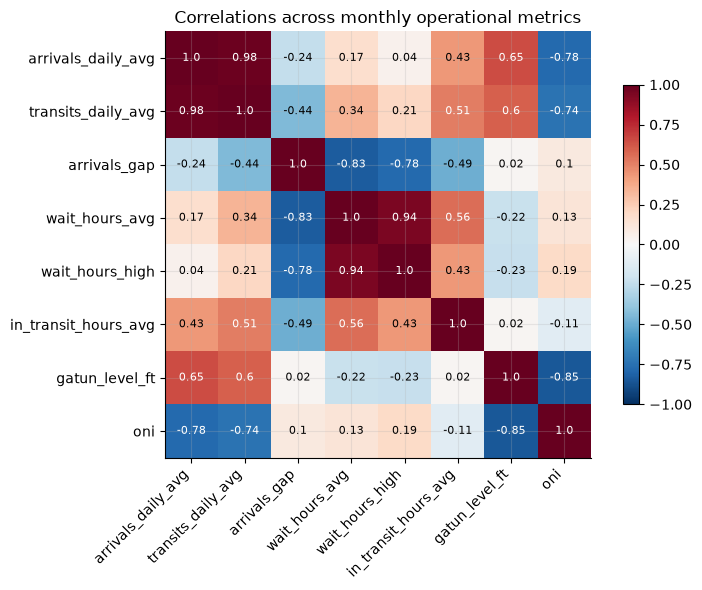

In [18]:
# Correlation matrix on the operational metrics + monthly-mean Gatun + ONI.
g = data["gatun"].assign(m=data["gatun"]["date"].dt.to_period("M"))
g_month = g.groupby("m", as_index=False)["gatun_level_ft"].mean()
g_month["month_start"] = g_month["m"].dt.to_timestamp()

o = data["enso"][["month_start", "oni"]]
mo_corr = (mo.merge(g_month[["month_start", "gatun_level_ft"]], on="month_start", how="left")
             .merge(o, on="month_start", how="left"))
cols = ["arrivals_daily_avg", "transits_daily_avg", "arrivals_gap",
        "wait_hours_avg", "wait_hours_high",
        "in_transit_hours_avg", "gatun_level_ft", "oni"]
corr = mo_corr[cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right"); ax.set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, corr.iloc[i, j], ha="center", va="center",
                color="white" if abs(corr.iloc[i, j]) > 0.5 else "black", fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.75)
ax.set_title("Correlations across monthly operational metrics")
plt.tight_layout(); plt.show()

### 12a. Time series panel

Three stories in three panels:
1. **Arrivals vs transits**: when arrivals > transits the queue is *growing*
   (a positive `arrivals_gap` is a leading indicator for wait time).
2. **Wait time**: the recovered target. Ribbon from avg → monthly high.
3. **In-transit time**: how long the crossing itself takes. Does it drift
   independent of the queue? (i.e. is the canal *slower* under drought
   even for vessels that never had to wait?)

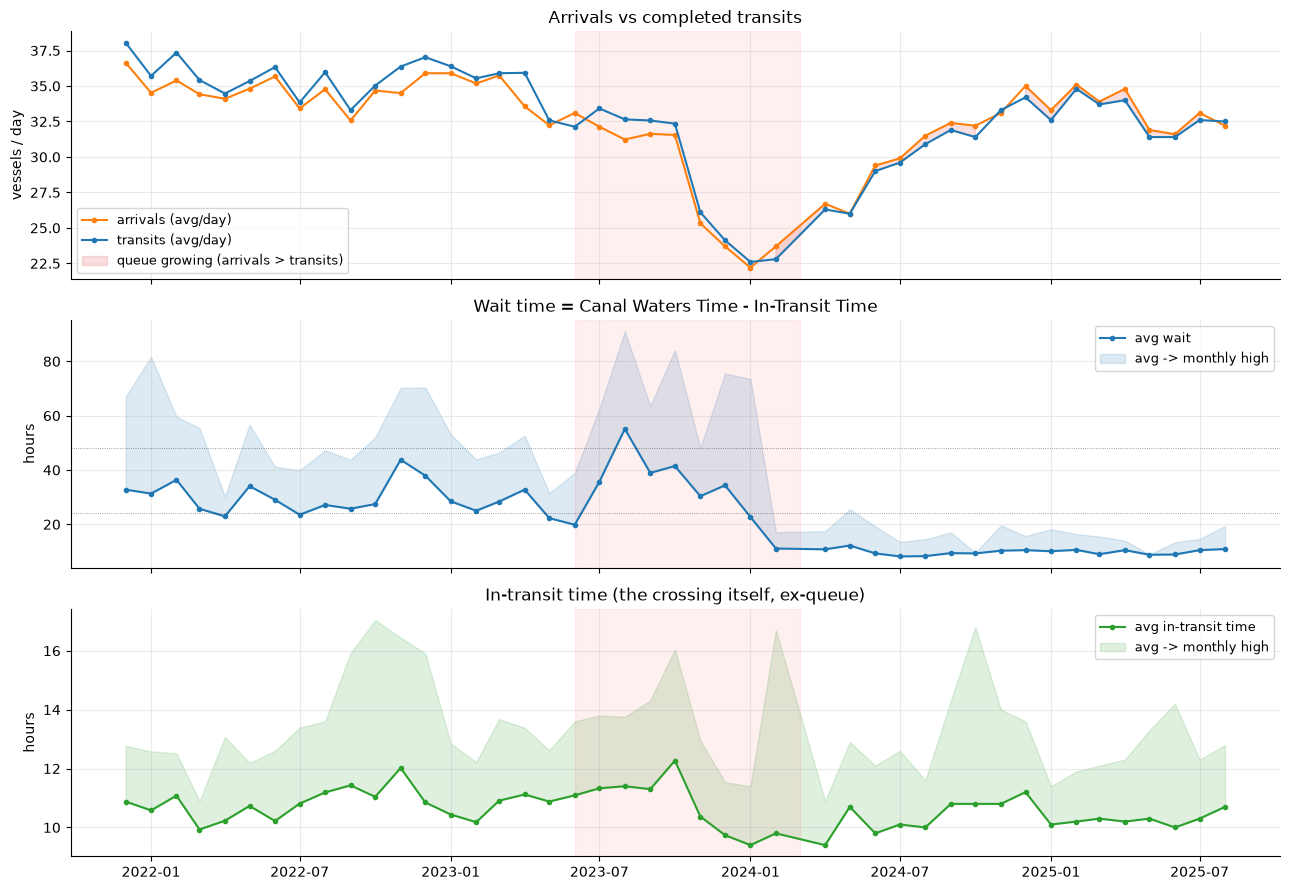

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(mo["month_start"], mo["arrivals_daily_avg"], color="C1", marker="o",
             ms=3, label="arrivals (avg/day)")
axes[0].plot(mo["month_start"], mo["transits_daily_avg"], color="C0", marker="o",
             ms=3, label="transits (avg/day)")
axes[0].fill_between(mo["month_start"], mo["transits_daily_avg"], mo["arrivals_daily_avg"],
                     where=mo["arrivals_daily_avg"] > mo["transits_daily_avg"],
                     color="C3", alpha=0.15, label="queue growing (arrivals > transits)")
axes[0].set_ylabel("vessels / day")
axes[0].legend(loc="lower left", fontsize=9)
axes[0].set_title("Arrivals vs completed transits")

axes[1].plot(mo["month_start"], mo["wait_hours_avg"], color="C0", marker="o", ms=3,
             label="avg wait")
axes[1].fill_between(mo["month_start"], mo["wait_hours_avg"], mo["wait_hours_high"],
                     color="C0", alpha=0.15, label="avg -> monthly high")
axes[1].axhline(24, color="k", ls=":", lw=0.6, alpha=0.5)
axes[1].axhline(48, color="k", ls=":", lw=0.6, alpha=0.5)
axes[1].set_ylabel("hours")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].set_title("Wait time = Canal Waters Time - In-Transit Time")

axes[2].plot(mo["month_start"], mo["in_transit_hours_avg"], color="C2", marker="o", ms=3,
             label="avg in-transit time")
axes[2].fill_between(mo["month_start"], mo["in_transit_hours_avg"], mo["in_transit_hours_high"],
                     color="C2", alpha=0.15, label="avg -> monthly high")
axes[2].set_ylabel("hours")
axes[2].legend(loc="upper right", fontsize=9)
axes[2].set_title("In-transit time (the crossing itself, ex-queue)")

for ax in axes:
    ax.axvspan(pd.Timestamp("2023-06-01"), pd.Timestamp("2024-03-01"),
               color="red", alpha=0.06)
plt.tight_layout(); plt.show()

### 12b. Drivers — the causal chain

`wait_hours` should respond to Gatun level (through the cap) and, at a lead,
to ONI. Plotting each relationship as a scatter coloured by year to see if
recent months are consistent with the historical pattern or if the ACP's
operational response to drought has shifted the curve.

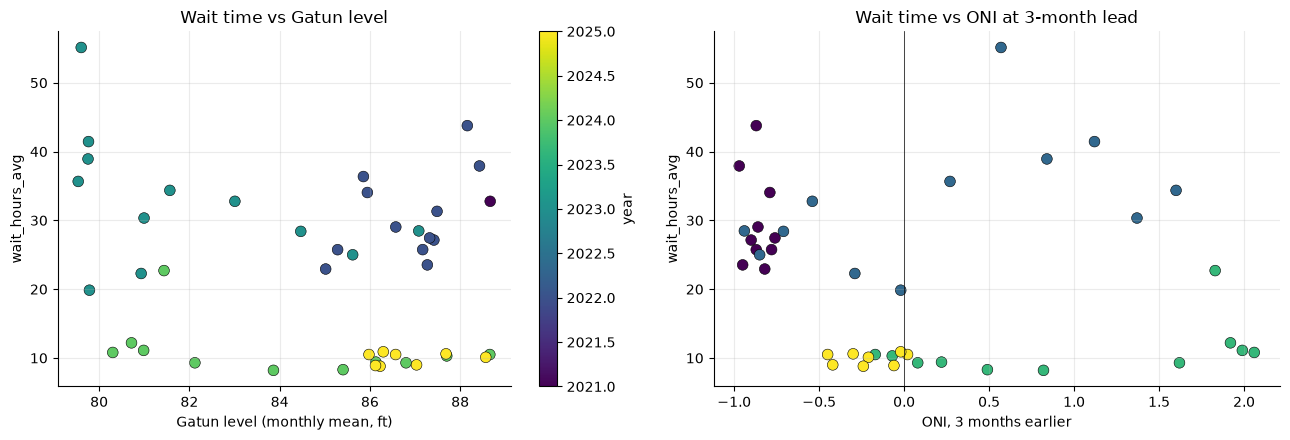

corr(wait_avg, gatun_level):     -0.22
corr(wait_avg, oni_lag3):        -0.17
corr(wait_avg, arrivals_gap):    -0.83


In [20]:
mo_j = mo_corr.copy()
mo_j["year"] = mo_j["month_start"].dt.year

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sc = axes[0].scatter(mo_j["gatun_level_ft"], mo_j["wait_hours_avg"],
                     c=mo_j["year"], cmap="viridis", s=60, edgecolor="k", lw=0.4)
axes[0].set_xlabel("Gatun level (monthly mean, ft)")
axes[0].set_ylabel("wait_hours_avg")
axes[0].set_title("Wait time vs Gatun level")
plt.colorbar(sc, ax=axes[0], label="year")

# ONI leads by ~3-6 months; try +3 month lead as illustrative
mo_j = mo_j.sort_values("month_start")
mo_j["oni_lag3"] = mo_j["oni"].shift(3)
axes[1].scatter(mo_j["oni_lag3"], mo_j["wait_hours_avg"],
                c=mo_j["year"], cmap="viridis", s=60, edgecolor="k", lw=0.4)
axes[1].axvline(0, color="k", lw=0.5)
axes[1].set_xlabel("ONI, 3 months earlier")
axes[1].set_ylabel("wait_hours_avg")
axes[1].set_title("Wait time vs ONI at 3-month lead")
plt.tight_layout(); plt.show()

print(f"corr(wait_avg, gatun_level):     {mo_j['wait_hours_avg'].corr(mo_j['gatun_level_ft']):+.2f}")
print(f"corr(wait_avg, oni_lag3):        {mo_j['wait_hours_avg'].corr(mo_j['oni_lag3']):+.2f}")
print(f"corr(wait_avg, arrivals_gap):    {mo_j['wait_hours_avg'].corr(mo_j['arrivals_gap']):+.2f}")

### 12c. Seasonality of wait time

Panama has a strong wet/dry cycle. Wait time should show seasonality if it's
tied to operational headroom rather than pure demand shocks. Two views:
month-of-year box plot to show climatology, and a year-over-year overlay to
see whether individual years deviate from the norm.

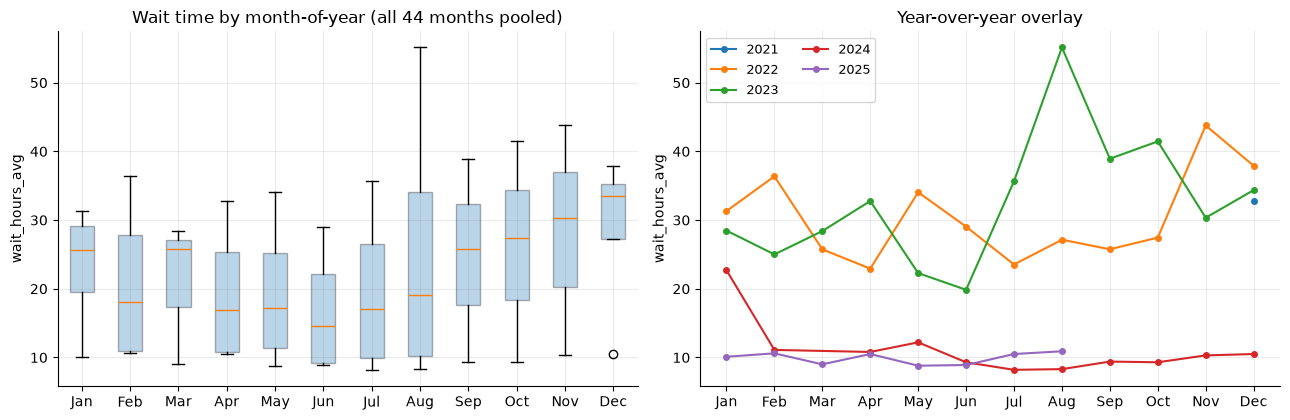

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
by_month = [mo.loc[mo["month_of_year"] == m, "wait_hours_avg"].dropna().values
            for m in range(1, 13)]
axes[0].boxplot(by_month, tick_labels=months, patch_artist=True,
                boxprops=dict(facecolor="C0", alpha=0.3))
axes[0].set_ylabel("wait_hours_avg")
axes[0].set_title("Wait time by month-of-year (all 44 months pooled)")

for year, sub in mo.groupby(mo["month_start"].dt.year):
    axes[1].plot(sub["month_of_year"], sub["wait_hours_avg"],
                 marker="o", ms=4, lw=1.5, label=str(year))
axes[1].set_xticks(range(1, 13)); axes[1].set_xticklabels(months)
axes[1].set_ylabel("wait_hours_avg")
axes[1].set_title("Year-over-year overlay")
axes[1].legend(loc="upper left", fontsize=9, ncol=2)
plt.tight_layout(); plt.show()